<a href="https://colab.research.google.com/github/SyedaFarahJaseemZaidi-ds/Titanic-Survival-Classification/blob/main/stock_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# Cell 1: Environment Setup
!pip install yfinance

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

print("Libraries successfully loaded!")

Libraries successfully loaded!


In [ ]:

# Cell 2: Fetch Data
# Define the stock ticker and the time period
ticker_symbol = 'AAPL'  # Apple Inc.
start_date = '2018-01-01'
end_date = '2026-01-01'

# Download data via yfinance
raw_data = yf.download(ticker_symbol, start=start_date, end=end_date)

# Drop any multi-level column names if yfinance defaults to them
raw_data.columns = raw_data.columns.get_level_values(0) if isinstance(raw_data.columns, pd.MultiIndex) else raw_data.columns

# Reset index to treat Date as a usable column
df = raw_data.reset_index()
print(f"Data successfully fetched for {ticker_symbol}!")
df.head()

/tmp/ipykernel_1655/556136621.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(ticker_symbol, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

Data successfully fetched for AAPL!


Price,Date,Close,High,Low,Open,Volume
0,2018-01-02,40.267075,40.276427,39.565802,39.776186,102223600
1,2018-01-03,40.260052,40.802371,40.196940,40.330180,118071600
2,2018-01-04,40.447079,40.549933,40.225010,40.332536,89738400
3,2018-01-05,40.907570,40.994059,40.451743,40.542909,94640000
4,2018-01-08,40.755630,41.050164,40.657449,40.755630,82271200


In [ ]:

# Cell 3: Data Preprocessing
# 1. Check for missing values and fill them if they exist
df.fillna(method='ffill', inplace=True)

# 2. Define the shift interval (e.g., predicting 5 days into the future)
forecast_out = 5

# 3. Create a target column shifted 'n' days up
df['Prediction'] = df[['Close']].shift(-forecast_out)

# 4. Define Independent Features (X) and Dependent Target (Y)
# We use Open, High, Low, Close, and Volume as indicators
feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
X = df[feature_cols].values

# Shift X alignment to matches prediction window constraints
X_model = X[:-forecast_out]
Y_model = df['Prediction'].dropna().values

print(f"Features (X) Shape: {X_model.shape}")
print(f"Target (Y) Shape: {Y_model.shape}")

Features (X) Shape: (2006, 5)
Target (Y) Shape: (2006,)


/tmp/ipykernel_1655/1086232320.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [ ]:

# Cell 4: Model Training
# Split data into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X_model, Y_model, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print("Linear Regression model successfully trained!")

Linear Regression model successfully trained!


In [ ]:
# Cell 5: Evaluation
# Generate predictions on the validation test set
y_pred = lr_model.predict(X_test)

# Calculate quantitative regression indicators
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"=== {ticker_symbol} Prediction Model Metrics ===")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared Score (R²): {r2:.4f}")

=== AAPL Prediction Model Metrics ===
Mean Absolute Error (MAE): 3.97
Root Mean Squared Error (RMSE): 5.71
R-squared Score (R²): 0.9930


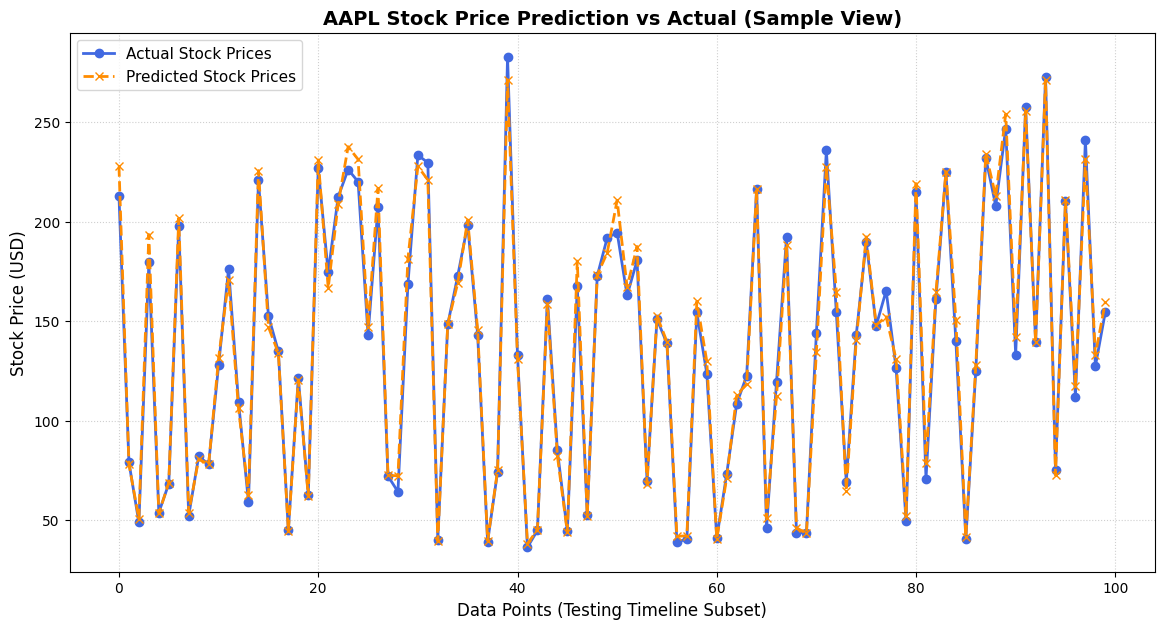

In [ ]:

# Cell 6: Visualizations
plt.figure(figsize=(14, 7))
plt.plot(y_test[:100], label='Actual Stock Prices', color='royalblue', linewidth=2, marker='o')
plt.plot(y_pred[:100], label='Predicted Stock Prices', color='darkorange', linewidth=2, linestyle='--', marker='x')

plt.title(f'{ticker_symbol} Stock Price Prediction vs Actual (Sample View)', fontsize=14, fontweight='bold')
plt.xlabel('Data Points (Testing Timeline Subset)', fontsize=12)
plt.ylabel('Stock Price (USD)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()